In [1]:
import os

import psutil

import spatioloji_s as sj

In [2]:
mem = psutil.virtual_memory()
print(f"Total memory available: {mem.total / 1024**3:.2f} GB")
cpus = os.cpu_count()
print(f"Total cpu cores available: {cpus}")
print(f"current work directory is {os.getcwd()}")

Total memory available: 251.40 GB
Total cpu cores available: 64
current work directory is /carc/scratch/projects/amitra2016502/spatioloji_s/example


In [3]:
# Load your spatioloji object
sp = sj.data.spatioloji.from_pickle('my_qc_output/data/filtered_spatioloji.pkl')


Loading spatioloji from: my_qc_output/data/filtered_spatioloji.pkl
✓ Loaded: 25,368 cells × 960 genes


In [4]:
# Normalize data
sj.processing.normalize_total(sp, target_sum=1e4, inplace=True)
sj.processing.log_transform(sp, layer='normalized_counts', inplace=True)

# Select highly variable genes
# # of HVG may be less than n_top_genes because we have other cut-off values to filter
sj.processing.highly_variable_genes(sp, n_top_genes=200, inplace=True, min_disp=0, min_mean=0)

# scale data
sj.processing.scale_by_batch_normalization(sp, layer='log_normalized', method='standard', max_value=10.0,
                                           batch_key='fov', output_layer="fov_scaled",inplace=True)

# Dimensionality reduction
sj.processing.pca(sp, n_comps=50, inplace=True, layer='fov_scaled')
sj.processing.umap(sp, use_pca=True, inplace=True, n_neighbors=30, n_pcs=20, min_dist=0.3)




Normalizing expression to target sum: 10,000
  Counts per cell - mean: 179, median: 140
  ✓ Normalized 25,368 cells × 960 genes
✓ Added layer 'normalized_counts' (dense, 185.8 MB)

Applying log transformation (base=e)
  ✓ Transformed 25,368 cells × 960 genes
✓ Added layer 'log_normalized' (dense, 185.8 MB)

Identifying highly variable genes (method=seurat)
  Using Seurat method (n_top_genes=200)
  ✓ Selected 200 highly variable genes
    Mean expression range: 0.02 - 2.63

Batch-wise scaling (batch_key='fov', method=standard)
  Found 20 batches
  Clipped values to [-10.0, 10.0]
  ✓ Scaled 25,368 cells × 960 genes across batches
✓ Added layer 'fov_scaled' (dense, 185.8 MB)

Computing PCA (n_comps=50)
  Using 200 highly variable genes
  Running PCA...
  ✓ PCA complete
    Variance explained by first 10 PCs: 17.8%
    Variance explained by all 50 PCs: 39.1%


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 00:01:03.463630: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 00:01:03.516554: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 00:01:05.621430: I tensorflow/c


UMAP (n_components=2, n_neighbors=30, min_dist=0.3)
  Using first 20 PCs as input
  Running UMAP...


/users/jiwang1/.conda/envs/spatioloji/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  ✓ UMAP complete


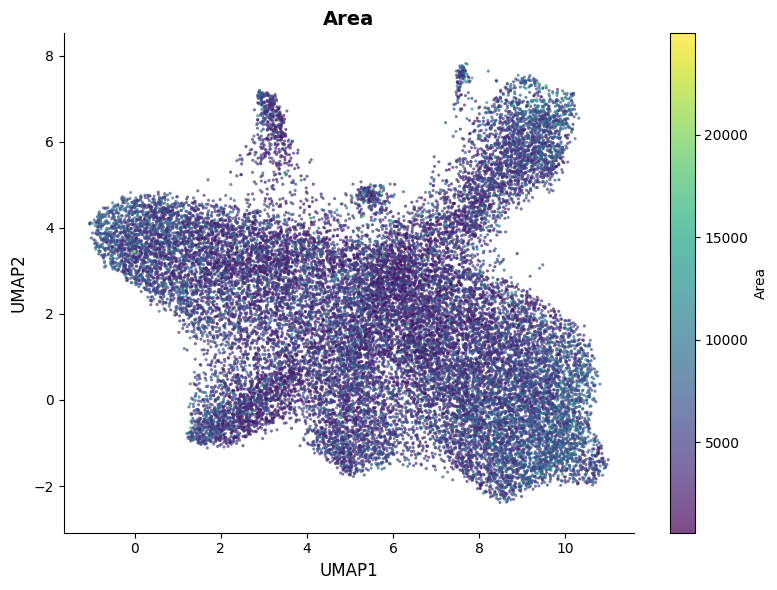

In [5]:
sj.visualization.plot_umap(sp,
                           color_by='Area',
                           show=True)

In [6]:
sj.processing.knn_smooth(
    sp,
    layer        = "log_normalized",
    n_neighbors  = 15,
    output_layer = "knn_smoothed",
    use_highly_variable=False
)


k-NN smoothing (n_neighbors=15)
  Using first 50 PCs for neighbor finding
  Building k-NN graph...
  Smoothing expression...
  ✓ k-NN smoothing complete
✓ Added layer 'knn_smoothed' (dense, 185.8 MB)


In [7]:
sj.processing.magic_impute(
    sp,
    layer        = "log_normalized",
    knn          = 5,
    t            = 3,
    conda_env    = "magic_env",      # omit if installed in current env
    output_layer = "magic_imputed",
    use_highly_variable=False
)


MAGIC imputation (knn=5, t=3)
  Running MAGIC in conda environment: 'magic_env'
    Calling conda environment 'magic_env'...
Input shape: (25368, 960)
n_pca: 100, knn: 5, t: 3
Building k-NN graph...
Running MAGIC diffusion...
Calculating MAGIC...
  Running MAGIC on 25368 cells and 960 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.99 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.79 seconds.
    Calculating affinities...
    Calculated affinities in 1.07 seconds.
  Calculated graph and diffusion operator in 2.88 seconds.
  Calculating imputation...
  Calculated imputation in 1.98 seconds.
Calculated MAGIC in 4.88 seconds.
MAGIC imputation complete!
Output shape: (25368, 960)


  ✓ MAGIC imputation complete
✓ Added layer 'magic_imputed' (dense, 185.8 MB)


In [8]:
sj.processing.alra_impute(
    sp,
    layer        = "log_normalized",
    k            = None,           # auto rank selection
    output_layer = "alra_imputed",
    conda_env = 'alra_imputed',
    use_highly_variable=False
)


ALRA imputation
  Running ALRA in conda environment: 'alra_imputed'
Selected rank: 24
Read matrix with 25368 cells and 960 genes
Find the 0.001 quantile of each gene
Sweep
Scaling all except for 0 columns
0.00% of the values became negative in the scaling process and were set to zero
The matrix went from 9.30% nonzero to 65.37% nonzero
ALRA done!


  ✓ ALRA imputation complete
✓ Added layer 'alra_imputed' (dense, 185.8 MB)


In [9]:
sj.processing.scvi_impute(sp, use_highly_variable=False, layer=None,
                           early_stopping=False, early_stopping_patience=15,
                           batch_size=512, conda_env='scvi_imputed', output_layer='scvi_imputed',
                           batch_key='fov')


scVI imputation (n_latent=30)
  Running scVI in conda environment: 'scvi_imputed'

Epoch 100/315:  31%|▎| 99/315 [02:40<05:50,  1.62s/it, v_num=1, train_loss=285]
Epoch 100/315:  32%|▎| 100/315 [02:42<05:49,  1.62s/it, v_num=1, train_loss=285
Epoch 100/315:  32%|▎| 100/315 [02:42<05:49,  1.62s/it, v_num=1, train_loss=285
Epoch 101/315:  32%|▎| 100/315 [02:42<05:49,  1.62s/it, v_num=1, train_loss=285
Epoch 101/315:  32%|▎| 101/315 [02:43<05:49,  1.63s/it, v_num=1, train_loss=285
Epoch 101/315:  32%|▎| 101/315 [02:43<05:49,  1.63s/it, v_num=1, train_loss=285
Epoch 102/315:  32%|▎| 101/315 [02:43<05:49,  1.63s/it, v_num=1, train_loss=285
Epoch 102/315:  32%|▎| 102/315 [02:45<05:48,  1.64s/it, v_num=1, train_loss=285
Epoch 102/315:  32%|▎| 102/315 [02:45<05:48,  1.64s/it, v_num=1, train_loss=285
Epoch 103/315:  32%|▎| 102/315 [02:45<05:48,  1.64s/it, v_num=1, train_loss=285
Epoch 103/315:  33%|▎| 103/315 [02:47<05:45,  1.63s/it, v_num=1, train_loss=285
Epoch 103/315:  33%|▎| 103/315 [02:4

In [10]:
sp.layers

{'normalized_counts': array([[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        , 104.16666667, ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]], shape=(25368, 960)),
 'log_normalized': array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 4.65554639, ..., 0.        , 0.        ,
         0. 

In [8]:
results = sj.processing.compare_imputation_methods(
    spatioloji_obj=sp,
    methods={
        "scvi": {
            "layer": None,                 # method can run on raw
            "batch_key": "fov",       # optional
            "n_latent": 30,
            "max_epochs": 200,
            "early_stopping": True,
            "batch_size": 512,
            "accelerator": "auto",
            "gene_likelihood": "zinb",
            "conda_env": "scvi_imputed",      # optional if separate env
            "use_highly_variable":False,
        },
        "magic": {
            "layer": "log_normalized",      # usually best on normalized/log data
            "knn": 5,
            "t": 3,
            "n_pca_components": 30,
            "conda_env": "magic_env",  # optional
            "use_highly_variable":False,
        },
        "alra": {
            "layer": "log_normalized",      # ALRA expects log-normalized
            "k": None,                      # auto rank
            "conda_env": "alra_imputed",      # optional
            "use_highly_variable":False,
        },
        "knn_smooth": {
            "layer": "log_normalized",
            "n_neighbors": 15,
            "n_pcs": 50,
            "use_pca": True,
            "use_highly_variable":False,
        },
    },
    layer="log_normalized",                 # reference layer for mask positions
    n_test_genes=100,
    mask_fraction=0.1,
    random_state=42,
    convert_raw_to_log_for_metrics=True,    # raw/count method outputs converted for fair metrics
)




Masking experiment: comparing ['scvi', 'magic', 'alra', 'knn_smooth']
  Reference layer : 'log_normalized'
  Mask fraction   : 10%
  Test genes      : 100 selected
  Masked values   : 20058

  [scvi] running on masked data...
✓ Added layer '_masked' (dense, 185.8 MB)

scVI imputation (n_latent=30)
  Running scVI in conda environment: 'scvi_imputed'

Epoch 100/200:  50%|▍| 99/200 [02:45<02:47,  1.66s/it, v_num=1, train_loss=283]
Epoch 100/200:  50%|▌| 100/200 [02:46<02:46,  1.66s/it, v_num=1, train_loss=283
Epoch 100/200:  50%|▌| 100/200 [02:46<02:46,  1.66s/it, v_num=1, train_loss=284
Epoch 101/200:  50%|▌| 100/200 [02:46<02:46,  1.66s/it, v_num=1, train_loss=284
Epoch 101/200:  50%|▌| 101/200 [02:48<02:44,  1.66s/it, v_num=1, train_loss=284
Epoch 101/200:  50%|▌| 101/200 [02:48<02:44,  1.66s/it, v_num=1, train_loss=284
Epoch 102/200:  50%|▌| 101/200 [02:48<02:44,  1.66s/it, v_num=1, train_loss=284
Epoch 102/200:  51%|▌| 102/200 [02:49<02:42,  1.66s/it, v_num=1, train_loss=284
Epoch 1

In [9]:
print(results)

       method     input_layer    metric_space  pearson_r  spearman_r      mse  \
0        scvi            None  log_normalized     0.3373      0.2964   4.4193   
1  knn_smooth  log_normalized          native     0.2081      0.0965  12.1817   
2       magic  log_normalized          native     0.1425      0.0267  11.5786   
3        alra  log_normalized          native    -0.2390     -0.2683   5.2144   

     rmse  variance_ratio  variance_calibration  zero_inflation_recovery  
0  2.1022          2.1275                0.0000                   0.0792  
1  3.4902          1.4613                0.4527                   0.6881  
2  3.4027          1.3633                0.5528                   0.0792  
3  2.2835          5.7644                0.0000                   0.4379  


In [11]:
sp.to_pickle("my_data_objects/impute.pkl")


Saving spatioloji to: my_data_objects/impute.pkl
✓ Saved (1298.8 MB)
